In [1]:
import pandas as pd 
import requests as requests
from bs4 import BeautifulSoup
import numpy as np 
from sqlalchemy import create_engine
import re
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
headers = {'User-Agent': 'Mozilla/5.0'}
base_url = "https://www.jumia.com.eg/mobile-phones/?page={}#catalog-listing"
max_url="https://www.jumia.com.eg/mobile-phones/?page=2#catalog-listing"

In [3]:
page = requests.get(max_url, headers=headers)
soup_page = BeautifulSoup(page.content, 'html.parser')


In [4]:
last_page_link = soup_page.find("a", attrs={"aria-label": "Last Page"}).get("href")
last_page= int(re.search(r'page=(\d+)', last_page_link).group(1))
last_page





26

In [5]:
jumia_samrt_phones = []           

for slice in range(1, last_page + 1):
    print(f"🔄 Scraping Page {slice}")
    url  = base_url.format(slice)

    res  = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(res.content, "html.parser")

    #find names  and prices
    names  = soup.find_all("h3", class_="name")
    prices = soup.find_all("div", class_="prc")

    
    for n_tag, p_tag in zip(names, prices):
        phone = {
            "name"  : n_tag.get_text(strip=True),      
            "price" : p_tag.get_text(strip=True)        
        }
        jumia_samrt_phones.append(phone)
    

🔄 Scraping Page 1
🔄 Scraping Page 2
🔄 Scraping Page 3
🔄 Scraping Page 4
🔄 Scraping Page 5
🔄 Scraping Page 6
🔄 Scraping Page 7
🔄 Scraping Page 8
🔄 Scraping Page 9
🔄 Scraping Page 10
🔄 Scraping Page 11
🔄 Scraping Page 12
🔄 Scraping Page 13
🔄 Scraping Page 14
🔄 Scraping Page 15
🔄 Scraping Page 16
🔄 Scraping Page 17
🔄 Scraping Page 18
🔄 Scraping Page 19
🔄 Scraping Page 20
🔄 Scraping Page 21
🔄 Scraping Page 22
🔄 Scraping Page 23
🔄 Scraping Page 24
🔄 Scraping Page 25
🔄 Scraping Page 26


In [2]:
df=pd.read_csv("jumia_smart_phones.csv")

# EDA

In [13]:
df

,name,price
0,Samsung A06 - 6.7 Inch 128GB/6GB Dual SIM 4G M...,4799.0
1,"Honor X7c - 6.7"" 256GB/8GB Dual SIM 4G Mobile ...",4799.0
2,Samsung A06 - 6.7 Inch 64GB/4GB Dual SIM 4G Mo...,8499.0
3,"Samsung Galaxy A16 - 6.7"" 256GB/8GB Dual SIM 4...",9249.0
4,"Samsung Galaxy A16 - 6.7"" 128GB/6GB Dual SIM 4...",5666.0
...,...,...
1030,Samsung Galaxy A6+ (2018) - 6.0-inch Dual SIM ...,4750.0
1031,Honor 10 Lite - 6.21-inch 64GB/3GB Mobile Phon...,3762.0
1032,XIAOMI Redmi 14C - 6.88 inch 256GB-8GB Dual SI...,6949.0
1033,Samsung A06 - 6.7 Inch 128GB/4GB Dual SIM 4G M...,5099.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 991 entries, 0 to 1034
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     991 non-null    object 
 1   price    991 non-null    float64
 2   Storage  972 non-null    object 
 3   brand    969 non-null    object 
 4   RAM      457 non-null    object 
dtypes: float64(1), object(4)
memory usage: 46.5+ KB


In [11]:
df["price"] = df["price"].str.replace("EGP", "").str.replace(",", "").astype(float)

C:\Users\DEll\AppData\Local\Temp\ipykernel_11772\1626539197.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


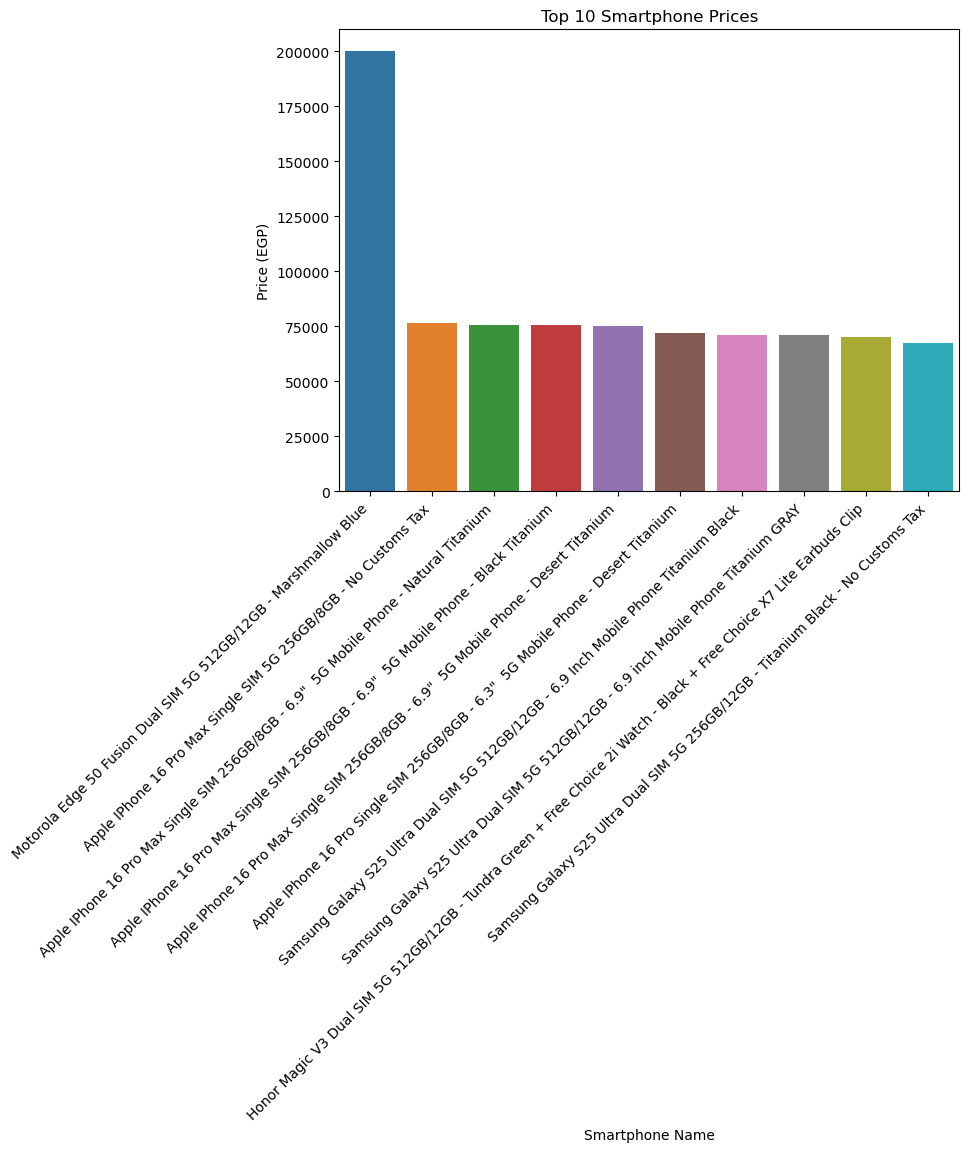

<Axes: ylabel='price'>

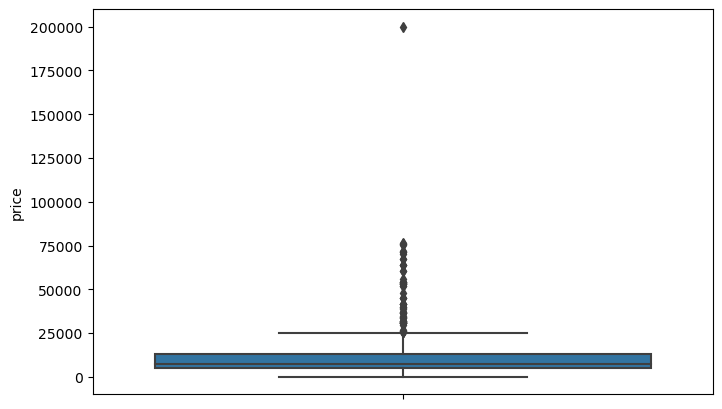

In [14]:
plt.figure(figsize=(8, 6))
top10 = df.sort_values('price', ascending=False).head(10)
sns.barplot(x="name", y="price", data=top10, )
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Smartphone Prices")
plt.ylabel("Price (EGP)")
plt.xlabel("Smartphone Name")
plt.tight_layout()
plt.show()

# Boxplot: price distribution
plt.figure(figsize=(8, 5))
sns.boxplot(y="price", data=df)


In [22]:
df.describe()

,price
count,991.000000
mean,11633.260040
std,12620.574996
min,1200.000000
25%,5508.000000
50%,7506.000000
75%,13792.000000
max,200000.000000


In [3]:
df = df[df["price"] > 1500]

In [5]:
brands = [
    "Samsung", "Xiaomi", "Infinix", "Apple", "OPPO", "Realme", "realme", "Vivo", "Itel", "itel",
    "Motorola", "Nokia", "HONOR", "Nothing", "Redmi", "POCO", "Tecno", "Blackview", "Asus",
    "CUBOT", "AllCall", "HUAWEI", "G-tide", "Girasole", "CMF", "DOOGEE", "ZTE","Hmd","CAT"
]
brand_pattern = '|'.join(brands)

In [6]:
df['Storage'] =  df['name'].str.extract(r'(32|64|128|256|512)')
df["brand"]=     df['name'].str.extract(f'({brand_pattern})', flags=re.IGNORECASE)


In [39]:

def extract_ram(name):
    # Find all numbers followed by GB in the string
    matches = re.findall(r'(\d+)GB', name)
    # Filter out values above 32GB (since realistic phone RAM is never >32)
    ram_candidates = [int(v) for v in matches if int(v) <= 32]
    if ram_candidates:
        # Pick first or last, depending on your preference/consistency
        # Let's pick the first one that is ≤ 32GB, as RAM may now be before ROM!
        return f"{ram_candidates[0]}GB"
    return None

df['RAM'] = df['name'].apply(extract_ram)


C:\Users\DEll\AppData\Local\Temp\ipykernel_11772\423298421.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RAM'] = df['name'].apply(extract_ram)


In [8]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 986 entries, 0 to 990
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     986 non-null    object 
 1   price    986 non-null    float64
 2   Storage  972 non-null    object 
 3   brand    981 non-null    object 
 4   RAM      942 non-null    object 
dtypes: float64(1), object(4)
memory usage: 46.2+ KB


,name,price,Storage,brand,RAM
0,Samsung A06 - 6.7 Inch 128GB/6GB Dual SIM 4G M...,4799.0,128,Samsung,6GB
1,"Honor X7c - 6.7"" 256GB/8GB Dual SIM 4G Mobile ...",4799.0,256,Honor,8GB
2,Samsung A06 - 6.7 Inch 64GB/4GB Dual SIM 4G Mo...,8499.0,64,Samsung,4GB
3,"Samsung Galaxy A16 - 6.7"" 256GB/8GB Dual SIM 4...",9249.0,256,Samsung,8GB
4,"Samsung Galaxy A16 - 6.7"" 128GB/6GB Dual SIM 4...",5666.0,128,Samsung,6GB
...,...,...,...,...,...
986,Samsung Galaxy A6+ (2018) - 6.0-inch Dual SIM ...,4750.0,64,Samsung,NaN
987,Honor 10 Lite - 6.21-inch 64GB/3GB Mobile Phon...,3762.0,64,Honor,3GB
988,XIAOMI Redmi 14C - 6.88 inch 256GB-8GB Dual SI...,6949.0,256,XIAOMI,8GB
989,Samsung A06 - 6.7 Inch 128GB/4GB Dual SIM 4G M...,5099.0,128,Samsung,4GB


In [7]:
df.to_csv("jumia_smart_phones.csv", index=False)


